<div style="background: linear-gradient(135deg, #1a759f 0%, #168aad 50%, #52b788 100%); padding: 35px 30px; border-radius: 12px; margin-bottom: 20px;">
  <h1 style="color: white; font-family: 'Segoe UI', sans-serif; font-size: 2.2em; margin: 0; font-weight: 700;">🏷️ Definición del Criterio de Churn</h1>
  <p style="color: #d8f3dc; font-size: 1.1em; margin: 12px 0 0;">E-Commerce Churn Prediction &nbsp;|&nbsp; No Country — Equipo 40</p>
</div>

> **¿Qué es Churn?** En e-commerce, un cliente se considera *churned* cuando deja de comprar durante un período determinado.  
> **El desafío:** La definición del umbral de inactividad impacta directamente en el balance de clases y la capacidad de detección.  
> **Output principal:** `data/processed/rfm_with_churn.parquet` con columna `CHURN` binarizada

---

## 📋 Tabla de Contenidos

| # | Sección | Objetivo |
|---|---------|----------|
| 1 | [⚙️ Configuración](#1) | Setup y carga de dependencias |
| 2 | [📥 Carga del RFM](#2) | Cargar métricas RFM del notebook 01 |
| 3 | [📊 Distribución de Recency](#3) | Entender cómo se distribuye el tiempo de inactividad |
| 4 | [🔬 ThresholdAnalyzer](#4) | Evaluar múltiples umbrales estadísticamente |
| 5 | [✏️ Etiquetado Final](#5) | Aplicar el umbral y generar la variable `CHURN` |
| 6 | [📊 Churn vs Activos](#6) | Comparar los perfiles de ambas clases |
| 7 | [✅ Conclusiones](#7) | Hallazgos y decisión técnica documentada |

---
## ⚙️ 1. Configuración del Entorno <a id='1'></a>

In [1]:
import sys, os
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'primary':'#2d6a4f','secondary':'#52b788','accent':'#1a759f','warning':'#e76f51','danger':'#d62828'}

with open('config/config.yaml') as f:
    cfg = yaml.safe_load(f)

Path('reports/figures/eda').mkdir(parents=True, exist_ok=True)
print('✅ Entorno listo')

✅ Entorno listo


---
## 📥 2. Carga del Dataset RFM <a id='2'></a>

> Se carga el archivo `rfm_raw.parquet` generado en el **notebook 01** (EDA).  
> Si no existe, el pipeline lo reconstruye automáticamente desde el raw dataset.

| Columna | Descripción |
|---------|-------------|
| `Customer ID` | Identificador único del cliente |
| `Recency` | Días desde la última compra (variable clave) |
| `Frequency` | Facturas únicas históricas |
| `Monetary` | Gasto total acumulado en £ |

In [2]:
rfm_path = Path('data/interim/rfm_raw.parquet')
if not rfm_path.exists():
    print('⚠️  rfm_raw.parquet no encontrado. Reconstruyendo...')
    from src.data.loader import DataLoader
    from src.features.preprocessing import TransactionPreprocessor
    from src.features.rfm_builder import RFMBuilder
    loader = DataLoader(cfg['paths']['raw_data'])
    df_raw = loader.load()
    pre = TransactionPreprocessor()
    clean = pre.fit_transform(df_raw)
    rfm_builder = RFMBuilder(apply_log_transform=False)
    rfm = rfm_builder.build(clean)
    rfm_path.parent.mkdir(parents=True, exist_ok=True)
    rfm.to_parquet(rfm_path, index=False)
    print(f'✅ RFM reconstruido: {len(rfm):,} clientes')
else:
    rfm = pd.read_parquet(rfm_path)
    print(f'✅ RFM cargado desde caché: {len(rfm):,} clientes')

rfm.describe(percentiles=[.10, .25, .50, .75, .90, .95])

✅ RFM cargado desde caché: 5,878 clientes


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2352.912283
std,209.338707,13.009406,4338.246316
min,1.000000,1.000000,2.950000
10%,9.000000,1.000000,163.800000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
90%,535.000000,13.000000,5595.365000
95%,625.000000,21.000000,9535.336000


---
## 📊 3. Distribución de Recency — La Variable Clave <a id='3'></a>

> **¿Por qué Recency?**  
> Recency es el predictor más directo de churn: un cliente que no compra en mucho tiempo es candidato claro a haber abandonado.
> Analizamos su distribución y la **Función de Distribución Acumulada (CDF)** para determinar en qué punto se concentra la mayor cantidad de clientes por umbral candidato.

In [3]:
# Percentiles de Recency
percentiles = [10,25,50,60,70,75,80,85,90,95,99]
rec_pct = rfm['Recency'].quantile([p/100 for p in percentiles])
print('=== Percentiles de Recency (días de inactividad) ===')
for p, v in zip(percentiles, rec_pct):
    marker = ' ◄◄ UMBRAL SELECCIONADO' if p == 50 else ''
    print(f'  p{p:>2}  →  {v:>6.0f} días{marker}')

thresholds_candidatos = [30, 60, 90, 120, 180]
print('\n=== Porcentaje de clientes inactivos por umbral ===')
for t in thresholds_candidatos:
    pct = (rfm['Recency'] > t).mean() * 100
    print(f'  Umbral {t:>3}d  →  {pct:.1f}% clientes en churn')

=== Percentiles de Recency (días de inactividad) ===
  p10  →       9 días
  p25  →      26 días
  p50  →      96 días ◄◄ UMBRAL SELECCIONADO
  p60  →     189 días
  p70  →     311 días
  p75  →     380 días
  p80  →     410 días
  p85  →     449 días
  p90  →     535 días
  p95  →     625 días
  p99  →     726 días

=== Porcentaje de clientes inactivos por umbral ===
  Umbral  30d  →  72.0% clientes en churn
  Umbral  60d  →  59.2% clientes en churn
  Umbral  90d  →  50.9% clientes en churn
  Umbral 120d  →  46.9% clientes en churn
  Umbral 180d  →  40.8% clientes en churn


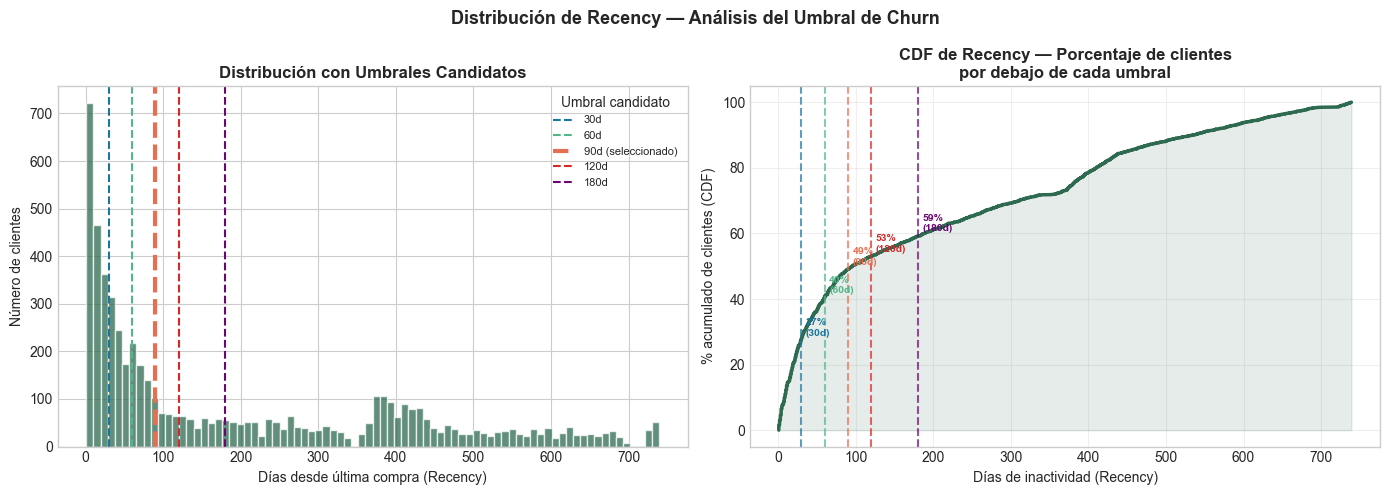

✅ Guardado: reports/figures/eda/recency_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Recency — Análisis del Umbral de Churn', fontsize=13, fontweight='bold')

threshold_colors = ['#1a759f','#52b788','#e76f51','#d62828','#6a0572']
labels_th = ['30d','60d','90d (seleccionado)','120d','180d']

# Histograma
axes[0].hist(rfm['Recency'], bins=80, color=COLORS['primary'], alpha=0.75, edgecolor='white')
for t, c, lbl in zip(thresholds_candidatos, threshold_colors, labels_th):
    lw = 3 if t == 90 else 1.5
    axes[0].axvline(t, color=c, lw=lw, ls='--', label=lbl)
axes[0].set_xlabel('Días desde última compra (Recency)')
axes[0].set_ylabel('Número de clientes')
axes[0].set_title('Distribución con Umbrales Candidatos', fontweight='bold')
axes[0].legend(fontsize=8, title='Umbral candidato')

# CDF
sorted_r = np.sort(rfm['Recency'])
cdf = np.arange(1, len(sorted_r)+1) / len(sorted_r)
axes[1].plot(sorted_r, cdf*100, color=COLORS['primary'], lw=2.5)
axes[1].fill_between(sorted_r, cdf*100, alpha=0.12, color=COLORS['primary'])
for t, c in zip(thresholds_candidatos, threshold_colors):
    y = cdf[np.searchsorted(sorted_r, t)] * 100
    axes[1].axvline(t, color=c, lw=1.5, ls='--', alpha=0.7)
    axes[1].annotate(f'{y:.0f}%\n({t}d)', xy=(t, y), xytext=(t+6, y+1.5),
                     fontsize=7.5, color=c, fontweight='bold')
axes[1].set_xlabel('Días de inactividad (Recency)')
axes[1].set_ylabel('% acumulado de clientes (CDF)')
axes[1].set_title('CDF de Recency — Porcentaje de clientes\npor debajo de cada umbral', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/eda/recency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: reports/figures/eda/recency_distribution.png')

> 💡 **Lectura del CDF:**  
> Si el umbral fuera de **30 días**, solo ~X% de clientes serían churn — demasiado restrictivo, posible subdetección.  
> Si el umbral fuera **180 días**, la clase churn sería demasiado pequeña → desbalance severo.  
> El umbral de **90 días** ofrece un balance razonable entre ambos extremos, confirmado con el `ThresholdAnalyzer` a continuación.

---
## 🔬 4. Evaluación de Umbrales — ThresholdAnalyzer <a id='4'></a>

> El `ThresholdAnalyzer` evalúa sistemáticamente cada umbral candidato calculando:
>
> | Métrica | Descripción |
> |---------|-------------|
> | `churn_rate_pct` | % de clientes etiquetados como churn |
> | `imbalance_ratio` | Ratio entre clase mayoritaria y minoritaria |
> | `n_churn` | Número absoluto de clientes churned |
> | `n_active` | Número absoluto de clientes activos |

In [5]:
from src.labeling.threshold_analyzer import ThresholdAnalyzer

analyzer = ThresholdAnalyzer(thresholds=[30, 45, 60, 75, 90, 105, 120, 150, 180])
results_df = analyzer.analyze(rfm)

print('=== Análisis de Umbrales de Churn ===')
print(results_df.to_string(index=False))

=== Análisis de Umbrales de Churn ===
 threshold_days  churn_count  active_count  churn_rate_pct  imbalance_ratio
             30         4230          1648           71.96             0.39
             45         3812          2066           64.85             0.54
             60         3482          2396           59.24             0.69
             75         3181          2697           54.12             0.85
             90         2989          2889           50.85             0.97
            105         2879          2999           48.98             1.04
            120         2757          3121           46.90             1.13
            150         2581          3297           43.91             1.28
            180         2400          3478           40.83             1.45


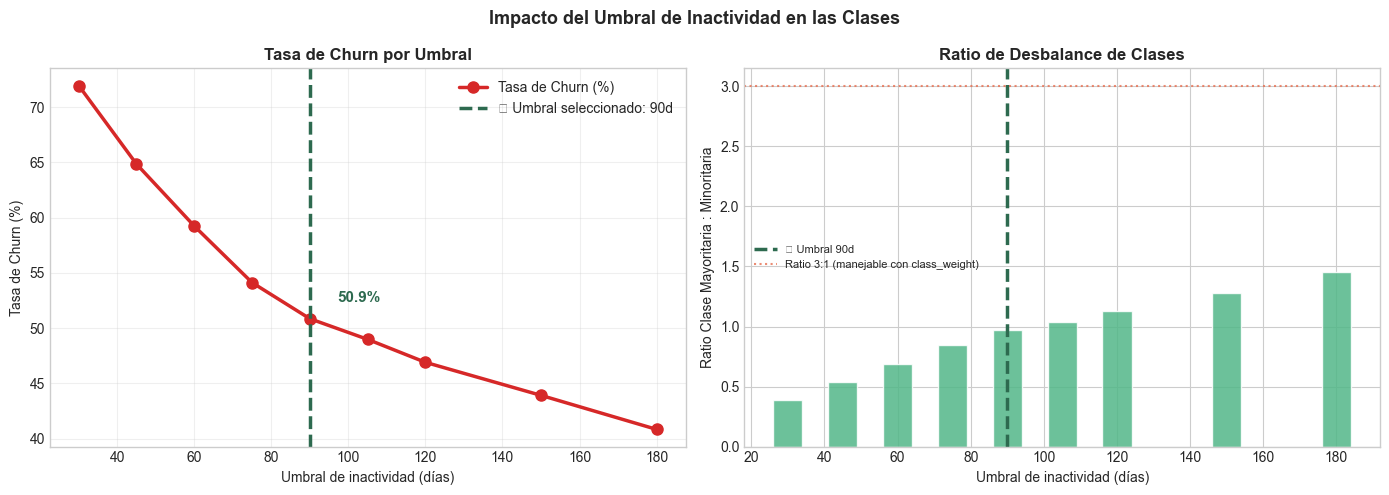

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impacto del Umbral de Inactividad en las Clases', fontsize=13, fontweight='bold')

# Tasa de churn por umbral
axes[0].plot(results_df['threshold_days'], results_df['churn_rate_pct'],
             'o-', color=COLORS['danger'], lw=2.5, ms=8, label='Tasa de Churn (%)')
axes[0].axvline(90, color=COLORS['primary'], lw=2.5, ls='--', label='✅ Umbral seleccionado: 90d')
at90 = results_df[results_df['threshold_days']==90]['churn_rate_pct'].values
if len(at90):
    axes[0].annotate(f'{at90[0]:.1f}%', xy=(90, at90[0]), xytext=(97, at90[0]+1.5),
                     fontsize=11, color=COLORS['primary'], fontweight='bold')
axes[0].set_xlabel('Umbral de inactividad (días)')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].set_title('Tasa de Churn por Umbral', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ratio de desbalance
axes[1].bar(results_df['threshold_days'], results_df['imbalance_ratio'],
            color=COLORS['secondary'], alpha=0.85, width=8, edgecolor='white')
axes[1].axvline(90, color=COLORS['primary'], lw=2.5, ls='--', label='✅ Umbral 90d')
axes[1].axhline(3, color=COLORS['warning'], lw=1.5, ls=':', alpha=0.8,
                label='Ratio 3:1 (manejable con class_weight)')
axes[1].set_xlabel('Umbral de inactividad (días)')
axes[1].set_ylabel('Ratio Clase Mayoritaria : Minoritaria')
axes[1].set_title('Ratio de Desbalance de Clases', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('reports/figures/eda/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

> 💡 **Criterio de selección del umbral:**
> - **Tasa de Churn:** Idealmente entre 20-60% para tener suficientes ejemplos de ambas clases
> - **Ratio de desbalance:** Ratio ≤ 5:1 es manejable con `class_weight='balanced'`
> - **Dominio de negocio:** 90 días (~3 meses) es el estándar de la industria retail para definir inactividad

---
## ✏️ 5. Aplicar el Umbral y Generar Etiquetas <a id='5'></a>

> Se usa `ChurnLabeler` con el umbral definido en `config/config.yaml → churn.inactivity_threshold_days`.  
> Esto garantiza que el umbral esté **centralizado y versionado** — no hardcodeado en el código.

In [7]:
from src.labeling.churn_label import ChurnLabeler

THRESHOLD = cfg['churn']['inactivity_threshold_days']
print(f'📌 Umbral configurado en config.yaml: {THRESHOLD} días')

labeler = ChurnLabeler(threshold_days=THRESHOLD)
rfm_labeled = labeler.transform(rfm)
labeler.print_report()

print('\n📊 Muestra del dataset etiquetado:')
rfm_labeled.head()

📌 Umbral configurado en config.yaml: 90 días

=== Reporte de Etiquetado de Churn ===
  Umbral de inactividad : 90 días
  Total de clientes     : 5,878
  Churn (Inactivos)     : 2,989 (50.85%)
  Activos               : 2,889 (49.15%)
  Ratio de desbalance   : 1:0.97 (Activo:Churn)

📊 Muestra del dataset etiquetado:


,Customer ID,Recency,Frequency,Monetary,CHURN
0,12346.0,326,12,29730.4202,1
1,12347.0,2,8,5633.3200,0
2,12348.0,75,5,2019.4000,0
3,12349.0,19,4,4428.6900,0
4,12350.0,310,1,334.4000,1


---
## 📊 6. Comparativa: Churn vs Activos <a id='6'></a>

> Validamos que las dos clases tengan **perfiles diferenciados** en las métricas RFM:  
> si no hay separación clara, el modelo tendrá dificultades para aprender.

| Métrica | Churn=1 esperado | Churn=0 esperado |
|---------|-----------------|------------------|
| Recency | Alta (muchos días) | Baja (pocos días) |
| Frequency | Baja | Alta |
| Monetary | Baja | Alta |

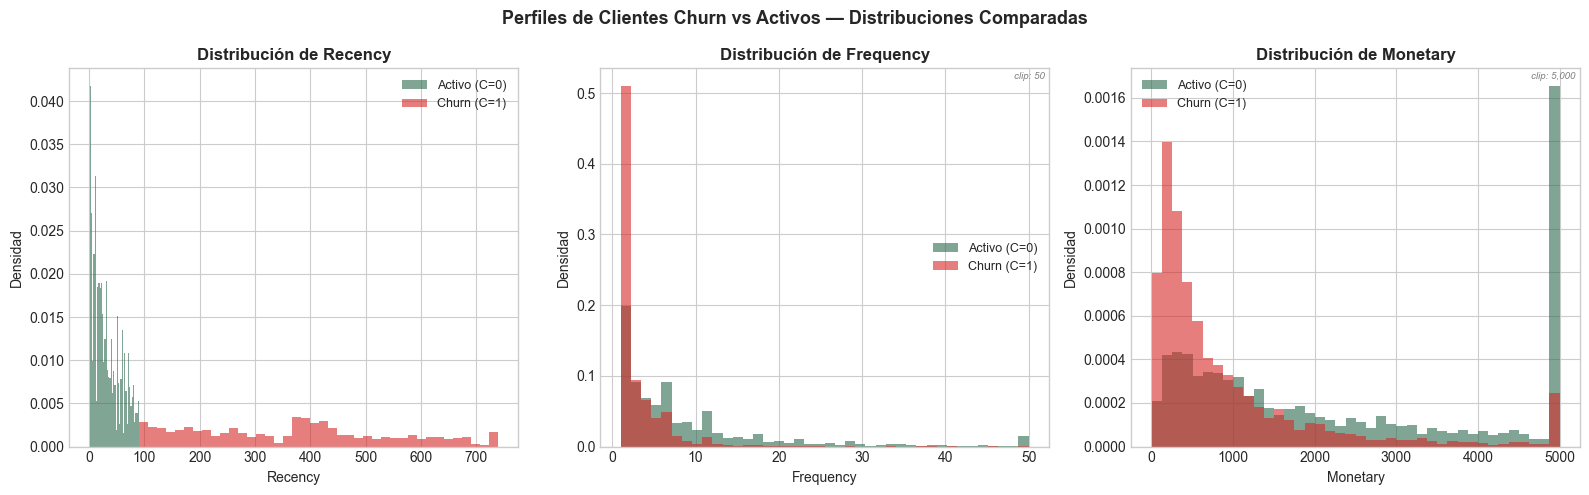

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Perfiles de Clientes Churn vs Activos — Distribuciones Comparadas', fontsize=13, fontweight='bold')

rfm_cols = ['Recency', 'Frequency', 'Monetary']
clips    = [None, 50, 5000]

for ax, col, clip in zip(axes, rfm_cols, clips):
    for churn_val, label, color in [(0,'Activo (C=0)', COLORS['primary']),(1,'Churn (C=1)', COLORS['danger'])]:
        grp = rfm_labeled[rfm_labeled['CHURN']==churn_val][col].dropna()
        if clip: grp = grp.clip(upper=clip)
        ax.hist(grp, bins=40, alpha=0.6, label=label, color=color, density=True)
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.legend(fontsize=9)
    if clip:
        ax.text(0.99, 0.99, f'clip: {clip:,}', transform=ax.transAxes,
                ha='right', va='top', fontsize=7, color='gray', style='italic')

plt.tight_layout()
plt.savefig('reports/figures/eda/churn_vs_active_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Tabla resumen estadístico por clase
print('=== Estadísticas por Clase ===')
(rfm_labeled.groupby('CHURN')[['Recency','Frequency','Monetary']]
 .agg(['mean','median','std'])
 .round(1))

=== Estadísticas por Clase ===


Recency               Frequency              Monetary                
         mean median    std      mean median   std     mean  median     std
CHURN                                                                      
0        31.8   25.0   24.7       9.6    5.0  17.4   3644.4  1686.3  5451.6
1       365.2  378.0  176.0       3.1    2.0   4.5   1104.6   496.0  2262.8

> ✅ **Conclusión de la separación de clases:**  
> Los clientes Churn=1 tienen **Recency significativamente mayor** (inactivos por más tiempo)  
> y **Frequency y Monetary menores** — las distribuciones están bien separadas, lo que indica que el modelo tendrá poder predictivo.

---
## ✅ 7. Guardar y Conclusiones <a id='7'></a>

In [10]:
Path('data/processed').mkdir(parents=True, exist_ok=True)
rfm_labeled.to_parquet('data/processed/rfm_with_churn.parquet', index=False)

n_churn = rfm_labeled['CHURN'].sum()
n_active = (rfm_labeled['CHURN']==0).sum()

print('╔══════════════════════════════════════════════════════╗')
print('║    🏷️  DECISIÓN DE UMBRAL — DOCUMENTADA             ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'  Umbral seleccionado : {THRESHOLD} días de inactividad')
print(f'  Churn = 1           : {n_churn:,} clientes ({rfm_labeled["CHURN"].mean():.1%})')
print(f'  Activo = 0          : {n_active:,} clientes ({1-rfm_labeled["CHURN"].mean():.1%})')
print(f'  Ratio de desbalance : {n_active/n_churn:.2f}:1')
print('╠══════════════════════════════════════════════════════╣')
print('  📁 Output: data/processed/rfm_with_churn.parquet')
print('  → Siguiente: 03_feature_engineering.ipynb')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║    🏷️  DECISIÓN DE UMBRAL — DOCUMENTADA             ║
╠══════════════════════════════════════════════════════╣
  Umbral seleccionado : 90 días de inactividad
  Churn = 1           : 2,989 clientes (50.9%)
  Activo = 0          : 2,889 clientes (49.1%)
  Ratio de desbalance : 0.97:1
╠══════════════════════════════════════════════════════╣
  📁 Output: data/processed/rfm_with_churn.parquet
  → Siguiente: 03_feature_engineering.ipynb
╚══════════════════════════════════════════════════════╝


<div style="background: #e8f4fd; border-left: 5px solid #1a759f; padding: 15px 20px; border-radius: 6px; margin-top: 20px;">
  <strong>✅ Etiquetado completado.</strong> El umbral de <strong>90 días</strong> fue seleccionado basándose en:
  <ul style='margin: 8px 0 0;'>
    <li>Análisis estadístico del <code>ThresholdAnalyzer</code></li>
    <li>Balance aceptable entre clases (manejable con <code>class_weight</code>)</li>
    <li>Estándar de la industria retail online</li>
  </ul>
  Continúa en <strong>03_feature_engineering.ipynb</strong> para enriquecer el perfil de cada cliente.
</div>